# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.

---

### Problem 1: Understanding the Data

This dataset represents 17 telephone marketing campaigns conducted by a Portuguese banking institution between May 2008 and November 2010. The campaigns promoted long-term deposit subscriptions. Across all campaigns there were 79,354 total contacts with a roughly 8% success rate


---

### Answer 1: Understanding the Data


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [20]:
# In order to keep the notbook clean my helper functions have been put into a util file. 
# This test is how I understand the CRISP-DM workflow and comparing classification models
# So I have helpers I use to undersand the sections but this notbook is deidcated to solving the core problem. 
from utils.helpers import profile_features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import time

In [21]:
pbi_marketing_campaigns = pd.read_csv('data/bank-additional-full.csv', sep=';')

In [22]:
pbi_marketing_campaigns.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

```markdown
### Input Variables

#### Bank Client Data
- **age**: *(numeric)*
- **job**: type of job *(categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')*
- **marital**: marital status *(categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)*
- **education**: *(categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')*
- **default**: has credit in default? *(categorical: 'no','yes','unknown')*
- **housing**: has housing loan? *(categorical: 'no','yes','unknown')*
- **loan**: has personal loan? *(categorical: 'no','yes','unknown')*

#### Related with the Last Contact of the Current Campaign
- **contact**: contact communication type *(categorical: 'cellular','telephone')*
- **month**: last contact month of year *(categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')*
- **day_of_week**: last contact day of the week *(categorical: 'mon','tue','wed','thu','fri')*
- **duration**: last contact duration, in seconds *(numeric)*.    
  > **Important Note:** this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call `y` is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

#### Other Attributes
- **campaign**: number of contacts performed during this campaign and for this client *(numeric, includes last contact)*
- **pdays**: number of days that passed by after the client was last contacted from a previous campaign *(numeric; 999 means client was not previously contacted)*
- **previous**: number of contacts performed before this campaign and for this client *(numeric)*
- **poutcome**: outcome of the previous marketing campaign *(categorical: 'failure','nonexistent','success')*

#### Social and Economic Context Attributes
- **employment_variation_rate** (`emp.var.rate`): quarterly change in employment levels *(numeric)*
- **consumer_price_index** (`cons.price.idx`): monthly measure of inflation / cost of goods *(numeric)*
- **consumer_confidence_index** (`cons.conf.idx`): monthly survey of how optimistic consumers feel about the economy *(numeric)*
- **euribor_3_month_rate** (`euribor3m`): daily interbank lending rate in the eurozone, reflects overall interest rate environment *(numeric)*
- **number_of_employees** (`nr.employed`): quarterly count of employed workers in the economy *(numeric)*

### Output Variable (Desired Target)
- **y**: has the client subscribed a term deposit? *(binary: 'yes','no')*
```

In [23]:
# Sending pbi_marketing_campaigns through profile_features to understand the fetures and data 
print(profile_features(pbi_marketing_campaigns))

                  dtype            inferred_type  n_unique  n_null  pct_null  \
column                                                                         
age               int64                  numeric        78       0       0.0   
job                 str              categorical        12       0       0.0   
marital             str              categorical         4       0       0.0   
education           str              categorical         8       0       0.0   
default             str              categorical         3       0       0.0   
housing             str              categorical         3       0       0.0   
loan                str              categorical         3       0       0.0   
contact             str                   binary         2       0       0.0   
month               str              categorical        10       0       0.0   
day_of_week         str              categorical         5       0       0.0   
duration          int64                 

### Problem 3: Findings
The dataset has no technical null values. However, several columns contain hidden missing data. The strings 'unknown' appear in default, housing, loan, job, education, and marital, acting as placeholders for missing information. The pdays column uses 999 as a sentinel to indicate a client was never previously contacted.

#### A few columns need special attention before modeling.

1. The `previous` column has only 8 unique integer values (0 through 7), which flagged it as low cardinality. However, the count of prior contacts carries real meaning since 3 previous contacts is more than 1. The original paper found number of previous contacts to be one of the top predictive features, so it stays numeric.

2. The month and day_of_week columns are categorical strings with an inherent order that standard one-hot encoding would lose. 

3. The duration column is the strongest predictor in the dataset, but it is only known after a call ends, so it should not be included in a realistic predictive model. 

4. The target variable y is stored as strings ('yes'/'no') and needs to be encoded to 0/1 before modeling.

5. `marital`, `default`, `housing`, `loan`, `job` and `education` all have missing values encoded as 'unknown'. We need to look at this more closely. 

6. `pdays` uses 999 instead of -1 like the original paper. This is a bit confusing, but after reviewing the data it appears that this dataset uses 999 to indicate a client was never previously contacted. 




Hidden Missing Values (as % of total rows)
----------------------------------------
default      20.9
education     4.2
housing       2.4
loan          2.4
job           0.8
marital       0.2

pdays (999 sentinel): 96.3% of users were never previously contacted


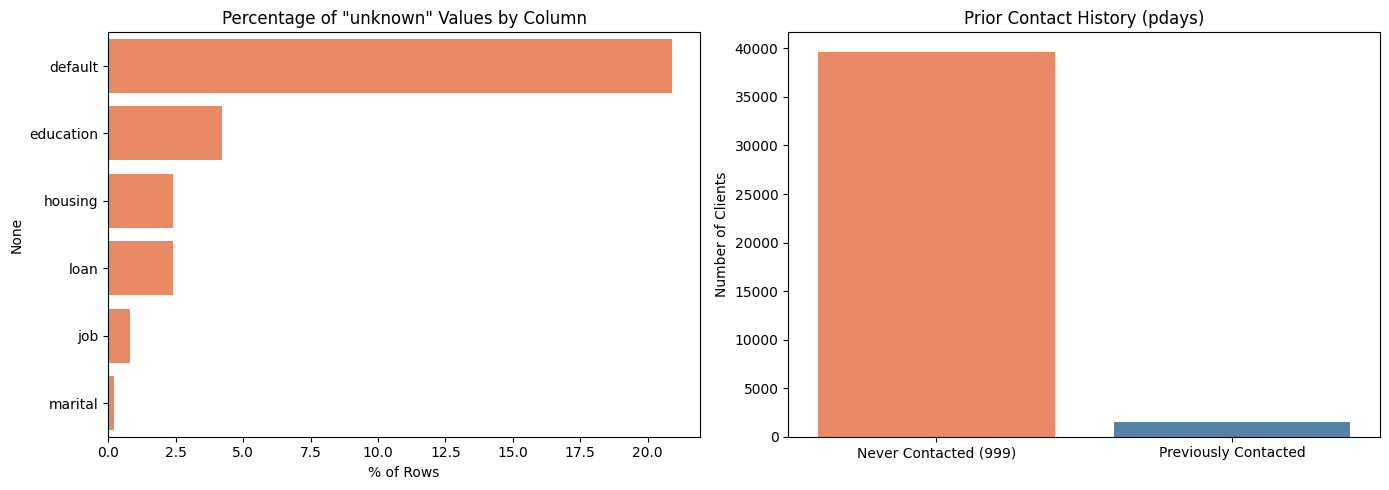

In [24]:
# Cell 1: Identify hidden missing values and what 999 means
# "unknown" strings in categorical columns
unknown_pct = (pbi_marketing_campaigns.isin(["unknown"]).sum() / len(pbi_marketing_campaigns) * 100).round(1)
unknown_pct = unknown_pct[unknown_pct > 0].sort_values(ascending=False)

# 999 sentinel in pdays
pdays_sentinel_pct = round((pbi_marketing_campaigns['pdays'] == 999).sum() / len(pbi_marketing_campaigns) * 100, 1)

print("Hidden Missing Values (as % of total rows)")
print("-" * 40)
print(unknown_pct.to_string())
print(f"\npdays (999 sentinel): {pdays_sentinel_pct}% of users were never previously contacted")


# Visualizing the the above 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: unknown percentages by column
sns.barplot(x=unknown_pct.values, y=unknown_pct.index, ax=axes[0], color='coral')
axes[0].set_title('Percentage of "unknown" Values by Column')
axes[0].set_xlabel('% of Rows')

# Right plot: pdays distribution (contacted vs never contacted)
pdays_labels = ['Never Contacted (999)', 'Previously Contacted']
pdays_counts = [(pbi_marketing_campaigns['pdays'] == 999).sum(), (pbi_marketing_campaigns['pdays'] != 999).sum()]
sns.barplot(x=pdays_labels, y=pdays_counts, hue=pdays_labels, ax=axes[1], palette=['coral', 'steelblue'], legend=False)
axes[1].set_title('Prior Contact History (pdays)')
axes[1].set_ylabel('Number of Clients')

plt.tight_layout()
plt.show()


#### Cell 1: Identify hidden missing values and what 999 means

After reviewing the data, it appears that the 999 sentinel in the pdays column indicates a client was never previously contacted which is -1 in the original paper and is the prodeminanat feature value qith most of the datasets users being cold calls. 

As far as unknown values, it appears that the `marital`, `default`, `housing`, `loan`, `job` and `education` columns all have missing values encoded as 'unknown' with default having the highest percentage of missing values at 20.9% of the dataset and we will need to handle these in our preprocessing step. 

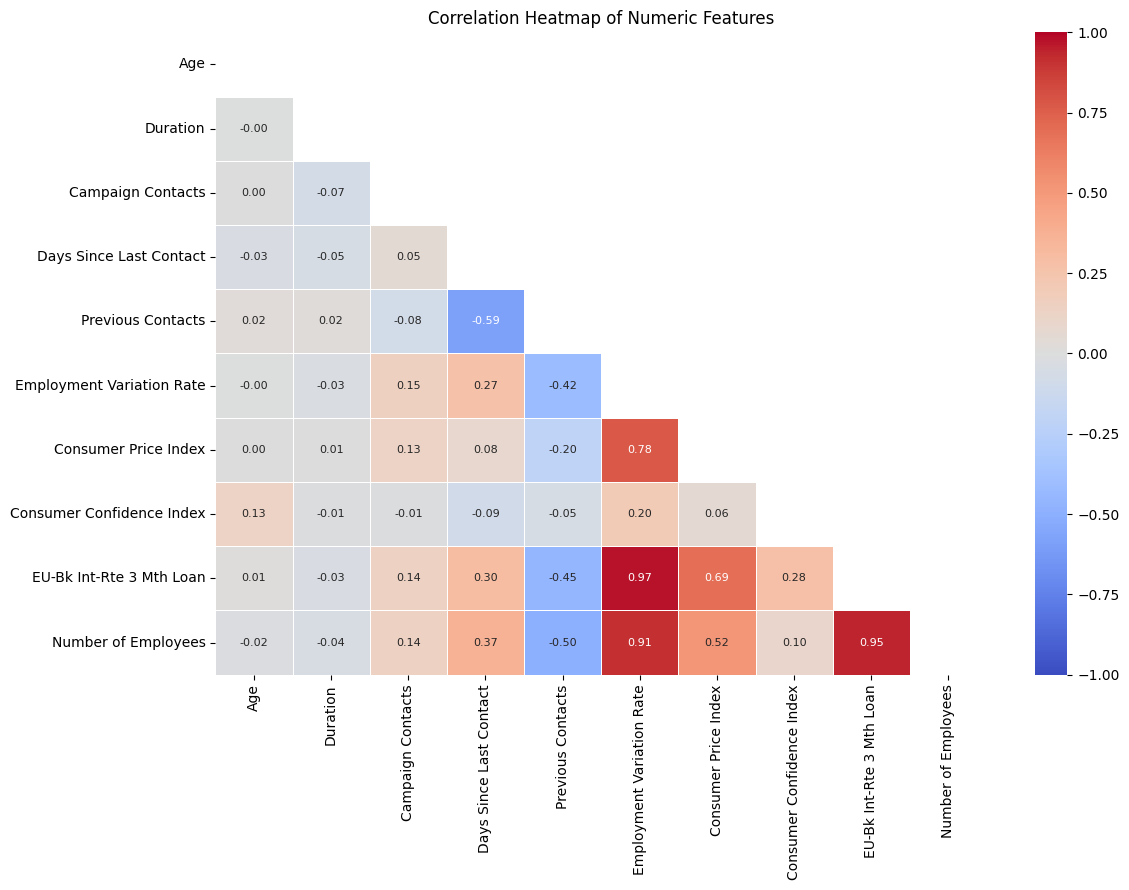

In [25]:
# Cell 2: Correlation heatmap for numeric features
numeric_cols = pbi_marketing_campaigns.select_dtypes(include=['float64', 'int64'])

# Rename columns for readability on the heatmap
readable_names = {
    'emp.var.rate': 'Employment Variation Rate',
    'cons.price.idx': 'Consumer Price Index',
    'cons.conf.idx': 'Consumer Confidence Index',
    'euribor3m': 'EU-Bk Int-Rte 3 Mth Loan',
    'nr.employed': 'Number of Employees',
    'age': 'Age',
    'duration': 'Duration',
    'campaign': 'Campaign Contacts',
    'pdays': 'Days Since Last Contact',
    'previous': 'Previous Contacts'
}
numeric_cols = numeric_cols.rename(columns=readable_names)

# Mask the upper triangle to reduce redundancy
mask = np.triu(np.ones_like(numeric_cols.corr(), dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(
    numeric_cols.corr(), 
    mask=mask,
    annot=True, 
    fmt=".2f",
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    annot_kws={"size": 8},
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

#### Cell 2: Correlation heatmap for numeric features
- Number of Employees and the Employment Variation Rate (EVR) have a high correlation of 0.91. 
- Euro Interbank Offered Rate and the Employment Variation Rate have the highest correlation of 0.97. 
- Euro Interbank Offered Rate and the Number of Employees have a correlation of 0.95. 

These three economic features are all measuring the same underlying thing — the state of the economy — which is why they correlate so strongly (0.91–0.97). This means they carry redundant information, and feeding all three into a model like Logistic Regression could make coefficient interpretation unreliable due to multicollinearity. The Employment Variation Rate captures the direction the economy is moving (jobs being added or lost), which is more telling than a raw employee count or a lending rate. When I get to Problem 5 (feature engineering), I can test models with all three vs. just the EVR to see if reducing redundancy improves performance.

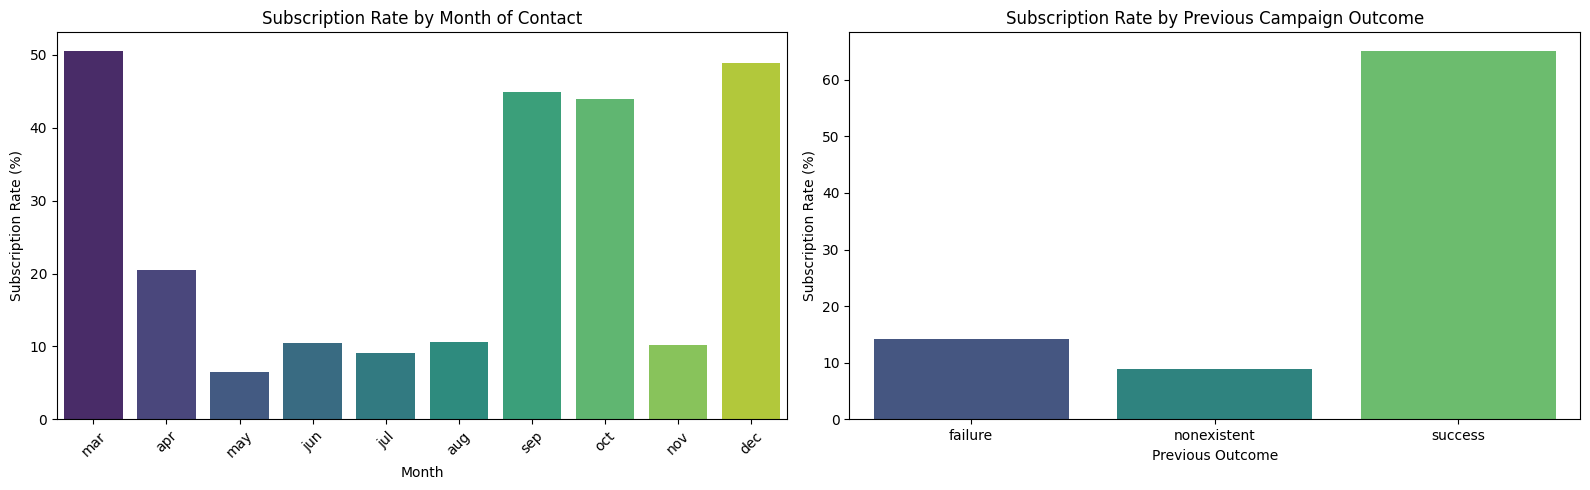

In [26]:
# Subscription rates by top categorical predictors identified in the paper
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Subscription rate by month (paper found end-of-quarter months performed best)
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_sub = pbi_marketing_campaigns.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100)
month_sub = month_sub.reindex(month_order).dropna()

sns.barplot(x=month_sub.index, y=month_sub.values, ax=axes[0], hue=month_sub.index, palette='viridis', legend=False)
axes[0].set_title('Subscription Rate by Month of Contact')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Right: Subscription rate by previous campaign outcome
poutcome_sub = pbi_marketing_campaigns.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean() * 100)

sns.barplot(x=poutcome_sub.index, y=poutcome_sub.values, ax=axes[1], hue=poutcome_sub.index, palette='viridis', legend=False)
axes[1].set_title('Subscription Rate by Previous Campaign Outcome')
axes[1].set_xlabel('Previous Outcome')
axes[1].set_ylabel('Subscription Rate (%)')

plt.tight_layout()
plt.show()

#### Cell 3: Subscription rates by top categorical predictors
**Month of Contact:** Certain months show dramatically higher subscription rates — March (50.5%), December (48.9%), September (44.9%), and October (43.9%) all far outperform the rest. These cluster around quarter transitions (end of Q1, start/end of Q4, end of Q3), suggesting that financial planning cycles may influence when clients are more receptive to deposit products. Meanwhile, May — which has the most contacts in the dataset — has the lowest rate at just 6.4%. The bank appears to be running high-volume campaigns in the worst-performing months.

**Previous Campaign Outcome:** Clients who previously subscribed (poutcome = 'success') have a 65.1% subscription rate — far higher than those who were never contacted (8.8%) or who previously declined (14.2%). This reinforces that follow-up with past subscribers is significantly more effective than cold calling, yet as we saw earlier, 96.3% of the dataset consists of cold contacts.

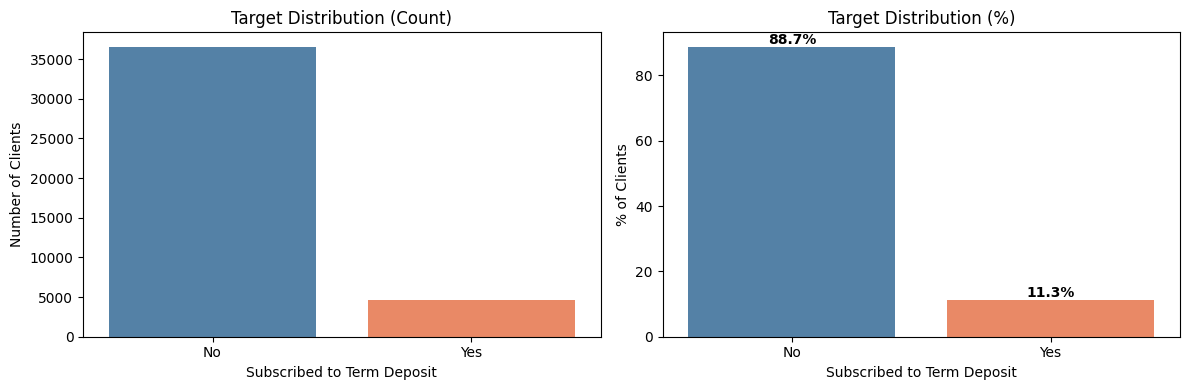

In [27]:
# Target variable distribution — visualize the class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw counts
sns.countplot(x='y', data=pbi_marketing_campaigns, ax=axes[0], hue='y', palette=['steelblue', 'coral'], legend=False)
axes[0].set_title('Target Distribution (Count)')
axes[0].set_xlabel('Subscribed to Term Deposit')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])
axes[0].set_ylabel('Number of Clients')

# Right: percentage
target_pct = pbi_marketing_campaigns['y'].value_counts(normalize=True) * 100
sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[1], hue=target_pct.index, palette=['steelblue', 'coral'], legend=False)
axes[1].set_title('Target Distribution (%)')
axes[1].set_xlabel('Subscribed to Term Deposit')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_ylabel('% of Clients')
for i, v in enumerate(target_pct.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---

### Problem 4: Business Objective

The bank wants to improve the efficiency of its telephone marketing campaigns for term deposit subscriptions. The goal is to build a classification model that predicts whether a client will subscribe (yes/no) based on their demographic, financial, and campaign contact data. A good model lets the bank focus outreach on clients most likely to convert, reducing the number of calls needed while maintaining or increasing the subscription rate. This means fewer wasted resources on cold calls that go nowhere.

---

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [28]:
# Step 1: column y and contact columns are easy since there are only two values  so we can encode to 0/1 
pbi_marketing_campaigns['y'] = pbi_marketing_campaigns['y'].map({'yes': 1, 'no': 0})
pbi_marketing_campaigns['contact'] = pbi_marketing_campaigns['contact'].map({'cellular': 1, 'telephone': 0})

# Step 2: Going Down the list of categorical columns and encoding them

## Job Column: Lets see how each value weighs in the target
# print(pbi_marketing_campaigns['job'].unique()) Uncomment to see the unique values of this column
# print("Job Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('job')['y'].mean().sort_values(ascending=False))
# Interesting findings, Students and Retired have the highest subscription rate at 31% and 25% respectively. 
# This is not what I originally thought, I thought a higher paying job would have a higher subscription rate. 
# Since there is no clear hierarchy I will one hot encode this column in a future step.

## Marital Column: 
# print("-" * 40)   
#print(pbi_marketing_campaigns['marital'].unique()) Uncomment to see the unique values of this column
# print("\nMarital Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('marital')['y'].mean().sort_values(ascending=False))

# Marital Column: unknown is actually the highest at 15%, single close behind at 14%.
# Married and divorced are nearly tied at ~10%. No inherent ranking.
# "unknown" has predictive value here so we keep it as its own category. One-hot encode.

## Month Column: 
# print("-" * 40)
# print(pbi_marketing_campaigns['month'].unique())  # Uncomment to see the unique values of this column
# print("\nMonth Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('month')['y'].mean().sort_values(ascending=False))

# Month Column: Huge variance. March (50.5%), December (48.9%), September (44.9%), October (43.9%) dominate.
# May has the most contacts but the lowest rate at 6.4%. The bank is calling the most in the worst month.
# There is a natural order (jan-dec) but the subscription rates don't follow that order at all. One-hot encode.


## Day of Week Column: 
# print("-" * 40)
# print(pbi_marketing_campaigns['day_of_week'].unique()) # Uncomment to see the unique values of this column
# print("\nDay of Week Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('day_of_week')['y'].mean().sort_values(ascending=False))
# Day of Week Column: Very tight spread from 9.9% (Monday) to 12.1% (Thursday).
# Not much signal here. No meaningful order since the rates don't follow mon-fri linearly. One-hot encode.

## Poutcome Column: 
# print("-" * 40)
# print(pbi_marketing_campaigns['poutcome'].unique()) # Uncomment to see the unique values of this column
# print("\nPoutcome Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('poutcome')['y'].mean().sort_values(ascending=False))

# Poutcome Column: Prior success is the strongest signal at 65.1% subscription rate.
# Failure still converts at 14.2%, nonexistent (never contacted) is lowest at 8.8%.
# No inherent order between these outcomes. One-hot encode.


## Education Column: 
# print("-" * 40)
# print(pbi_marketing_campaigns['education'].unique()) # Uncomment to see the unique values of this column
# print(pbi_marketing_campaigns['education'].value_counts()) # Uncomment to Check the counts of each value to fully understand the distribution
# print("\nEducation Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('education')['y'].mean().sort_values(ascending=False))
# Education Column: There is a rough ordering (basic.4y -> university.degree) where higher education
# correlates with higher subscription rates. However, "unknown" (1,731 rows, 14.5% sub rate) and 
# "illiterate" (only 18 rows, not statistically meaningful) don't fit cleanly in that ladder.
# Ordinal encoding would force us to either drop unknowns or assign them a fake rank.
# One-hot encode to preserve all the data and let the model learn each level independently.

## Default Column:
# print("-" * 40)
# print(pbi_marketing_campaigns['default'].unique()) # Uncomment to see the unique values of this column
# print(pbi_marketing_campaigns['default'].value_counts()) # Check the counts of each value to fully understand the distribution
# print("\nDefault Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('default')['y'].mean().sort_values(ascending=False))
# Default Column: Only 3 "yes" values currently, and 8,597 "unknown" (20.9%).
# "no" subscribes at 12.9% vs "unknown" at 5.2%, meaningful gap.
# Keeping all three values for future-proofing. If the bank improves data collection,
# "unknown" shrinks and "yes" becomes meaningful. One-hot encode.

## Housing Column: 
# print("-" * 40)
# print(pbi_marketing_campaigns['housing'].unique()) # Uncomment to see the unique values of this column
# print(pbi_marketing_campaigns['housing'].value_counts()) # Check the counts of each value to fully understand the distribution
# print("\nHousing Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('housing')['y'].mean().sort_values(ascending=False))
# Housing Column: Subscription rates nearly identical across all values (10.8%-11.6%).
# No meaningful predictive signal. Dropping to reduce noise.

## Loan Column: 
# print("-" * 40)
# print(pbi_marketing_campaigns['loan'].unique()) # Uncomment to see the unique values of this column
# print(pbi_marketing_campaigns['loan'].value_counts()) # Check the counts of each value to fully understand the distribution
# print("\nLoan Subscription Rate Sorted By Most Likely to Subscribe: \n \n", pbi_marketing_campaigns.groupby('loan')['y'].mean().sort_values(ascending=False))
# Loan Column: Same pattern as housing, rates flat (10.8%-11.3%).
# No meaningful predictive signal. Dropping to reduce noise.


## Pdays Column: 
# 96.3% of values are 999 (never contacted). For the 3.7% who were contacted,
# there is signal in the timing, but previous and poutcome already capture whether someone
# was contacted before and what happened. The 999 sentinel makes scaling unreliable.
# Dropping to avoid redundancy and scaling issues.


pbi_marketing_campaigns = pbi_marketing_campaigns.drop(columns=['loan', 'housing', 'pdays'])


## Economic Indicators: emp.var.rate, euribor3m, nr.employed, cons.price.idx, cons.conf.idx
# Correlation heatmap showed euribor3m (0.97) and nr.employed (0.91) are nearly identical to emp.var.rate.
# All five measure the state of the economy. Keeping only emp.var.rate as it captures
# employment direction (jobs added or lost), which is the most actionable for the bank.
# Dropping the other four to reduce multicollinearity.
pbi_marketing_campaigns = pbi_marketing_campaigns.drop(columns=['euribor3m', 'nr.employed', 'cons.price.idx', 'cons.conf.idx'])


## Duration Column: 
# Strongest predictor in the dataset, but it's only known after the call ends.
# Including it would be data leakage for a real predictive model.
# Will run models with and without duration to show benchmark vs realistic performance.



## Columns to one-hot encode
one_hot_encoder_list = [
    'job',
    'marital',
    'month',
    'day_of_week',
    'poutcome',
    'education',
    'default'
]

# Numeric features WITHOUT duration (realistic model — what the bank can actually use before a call)
numeric_features_realistic = [
    'age',
    'campaign',
    'previous',
    'emp.var.rate'
]

# Numeric features WITH duration (benchmark — shows how much duration matters)
numeric_features_benchmark = [
    'age',
    'duration',
    'campaign',
    'previous',
    'emp.var.rate'
]

# Binary features
binary_features_list = [
    'contact'
]

# Review the data
print("\nUpdated Data:")
pbi_marketing_campaigns.head()



Updated Data:


,age,job,marital,education,default,contact,month,day_of_week,duration,campaign,previous,poutcome,emp.var.rate,y
0,56,housemaid,married,basic.4y,no,0,may,mon,261,1,0,nonexistent,1.1,0
1,57,services,married,high.school,unknown,0,may,mon,149,1,0,nonexistent,1.1,0
2,37,services,married,high.school,no,0,may,mon,226,1,0,nonexistent,1.1,0
3,40,admin.,married,basic.6y,no,0,may,mon,151,1,0,nonexistent,1.1,0
4,56,services,married,high.school,no,0,may,mon,307,1,0,nonexistent,1.1,0


---
### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [29]:
# Separate features and target
X = pbi_marketing_campaigns.drop(columns=['y'])
y = pbi_marketing_campaigns['y']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True).round(3)}")

Training set size: (32950, 13)
Test set size: (8238, 13)
Training target distribution:
y
0    0.888
1    0.112
Name: proportion, dtype: float64


In [30]:
# Build TWO preprocessing pipelines: one realistic, one benchmark (with duration)

# Realistic preprocessor — no duration (what the bank can use before making a call)
preprocessor_realistic = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features_realistic),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_encoder_list),
    ('bin', 'passthrough', binary_features_list)
])

# Benchmark preprocessor — includes duration (shows the ceiling if we had perfect info)
preprocessor_benchmark = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features_benchmark),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_encoder_list),
    ('bin', 'passthrough', binary_features_list)
])

---
### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [31]:
# Baseline: what if we just predicted the majority class every time?
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Baseline accuracy (always predict 'no'): {baseline_accuracy:.4f}")
print(f"\nA model that predicts 'no' for every client gets {baseline_accuracy*100:.1f}% accuracy.")
print("Any useful model must beat this, but more importantly, it must actually identify subscribers.")
print("Since only ~11% of clients subscribe, accuracy alone is misleading.")
print("We will use F1-score as our primary metric to balance precision and recall.")

Baseline accuracy (always predict 'no'): 0.8876

A model that predicts 'no' for every client gets 88.8% accuracy.
Any useful model must beat this, but more importantly, it must actually identify subscribers.
Since only ~11% of clients subscribe, accuracy alone is misleading.
We will use F1-score as our primary metric to balance precision and recall.


---
### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [32]:
# Run Logistic Regression with BOTH preprocessors to show the impact of duration

# --- Benchmark model (WITH duration) ---
lr_benchmark = Pipeline(steps=[
    ('preprocessor', preprocessor_benchmark),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

start_time = time.time()
lr_benchmark.fit(X_train, y_train)
benchmark_time = time.time() - start_time

y_test_pred_bench = lr_benchmark.predict(X_test)

print("=" * 50)
print("BENCHMARK MODEL (with duration)")
print("=" * 50)
print(f"Train time: {benchmark_time:.4f} seconds")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred_bench):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_test_pred_bench):.4f}")
print(f"\n{classification_report(y_test, y_test_pred_bench)}")

# --- Realistic model (WITHOUT duration) ---
lr_realistic = Pipeline(steps=[
    ('preprocessor', preprocessor_realistic),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

start_time = time.time()
lr_realistic.fit(X_train, y_train)
realistic_time = time.time() - start_time

y_test_pred_real = lr_realistic.predict(X_test)

print("=" * 50)
print("REALISTIC MODEL (without duration)")
print("=" * 50)
print(f"Train time: {realistic_time:.4f} seconds")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred_real):.4f}")
print(f"Test F1-Score:  {f1_score(y_test, y_test_pred_real):.4f}")
print(f"\n{classification_report(y_test, y_test_pred_real)}")

print("\n" + "=" * 50)
print("IMPACT: Removing duration drops F1 from", 
      f"{f1_score(y_test, y_test_pred_bench):.4f} to {f1_score(y_test, y_test_pred_real):.4f}")
print("This confirms the paper's finding: duration is the strongest predictor,")
print("but it cannot be known before making the call.")

BENCHMARK MODEL (with duration)
Train time: 0.0819 seconds
Test Accuracy:  0.9107
Test F1-Score:  0.5132

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.41      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238

REALISTIC MODEL (without duration)
Train time: 0.0845 seconds
Test Accuracy:  0.8958
Test F1-Score:  0.3081

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7303
           1       0.63      0.20      0.31       935

    accuracy                           0.90      8238
   macro avg       0.77      0.59      0.63      8238
weighted avg       0.87      0.90      0.87      8238


IMPACT: Removing duration drops F1 from 0.5132 to 0.3081
This confirms the paper's finding: duration is the strongest predictor,
b

---
### Problem 9: Score the Model

**Benchmark Model (with duration):** Test accuracy of 91.1% with an F1-score of 0.51. Precision is 0.67 and recall is 0.41 — the model catches 41% of actual subscribers.

**Realistic Model (without duration):** Test accuracy of 89.6% with an F1-score of 0.31. Recall drops to just 20% — the model only catches 1 in 5 subscribers.

The gap between these two models confirms what the paper found: call duration is the single strongest predictor, but it cannot be known before making the call. A realistic model that the bank could deploy before dialing must work without it, and the F1 drop from 0.51 to 0.31 shows how much harder that makes the problem.

For the bank's use case, the realistic model's 20% recall is a serious concern. It means 80% of potential subscribers go untargeted. This is why we chose F1 as our primary metric — accuracy of 89.6% sounds good but is only 1% above the 88.8% baseline of always predicting "no." The model needs to actually find subscribers, not just be right most of the time.

The goal in Problems 10 and 11 is to compare other classifiers and tune hyperparameters to improve this F1 score without relying on duration.

---
### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [33]:


# Compare all four models using the REALISTIC preprocessor (no duration)
# This reflects what the bank can actually use before making calls
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor_realistic),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'KNN': Pipeline(steps=[
        ('preprocessor', preprocessor_realistic),
        ('classifier', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor_realistic),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'SVM': Pipeline(steps=[
        ('preprocessor', preprocessor_realistic),
        ('classifier', SVC(random_state=42))
    ]),
}

# Train and evaluate each model
results = []

for model_name, pipeline in models.items():
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    train_acc = accuracy_score(y_train, pipeline.predict(X_train))
    test_acc = accuracy_score(y_test, pipeline.predict(X_test))
    test_f1 = f1_score(y_test, pipeline.predict(X_test))
    
    results.append({
        'Model': model_name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4),
        'Test F1-Score': round(test_f1, 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy,Test F1-Score
Model,,,,
Logistic Regression,0.1259,0.8981,0.8958,0.3081
KNN,0.0356,0.9114,0.8858,0.2951
Decision Tree,0.2851,0.9860,0.8377,0.3105
SVM,34.3324,0.9011,0.8971,0.2898


---
### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [34]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='joblib')

# Define param grids for each model (accessing the classifier step in the pipeline)
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['lbfgs', 'liblinear']
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 9, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 10, 20, None],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf']
    }
}

# Run GridSearchCV for each model
tuned_results = []
best_estimators = {}

for model_name, pipeline in models.items():
    print(f"Tuning {model_name}...")
    
    grid = GridSearchCV(
        pipeline,
        param_grids[model_name],
        scoring='f1',
        cv=5,
        n_jobs=-1
    )
    
    start_time = time.time()
    grid.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    best_model = grid.best_estimator_
    best_estimators[model_name] = best_model
    y_test_pred = best_model.predict(X_test)
    
    tuned_results.append({
        'Model': model_name,
        'Best Params': grid.best_params_,
        'Best CV F1': round(grid.best_score_, 4),
        'Train Time (s)': round(train_time, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_test_pred), 4),
        'Test F1-Score': round(f1_score(y_test, y_test_pred), 4)
    })
    
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1: {grid.best_score_:.4f}")
    print(f"  Test F1: {f1_score(y_test, y_test_pred):.4f}\n")

tuned_df = pd.DataFrame(tuned_results).set_index('Model')
tuned_df

Tuning Logistic Regression...
  Best params: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
  Best CV F1: 0.3044
  Test F1: 0.3076

Tuning KNN...
  Best params: {'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}
  Best CV F1: 0.3201
  Test F1: 0.3166

Tuning Decision Tree...
  Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
  Best CV F1: 0.3538
  Test F1: 0.3308

Tuning SVM...
  Best params: {'classifier__C': 10, 'classifier__kernel': 'rbf'}
  Best CV F1: 0.3323
  Test F1: 0.3326



,Best Params,Best CV F1,Train Time (s),Test Accuracy,Test F1-Score
Model,,,,,
Logistic Regression,"{'classifier__C': 10, 'classifier__solver': 'l...",0.3044,2.1779,0.8956,0.3076
KNN,"{'classifier__n_neighbors': 3, 'classifier__we...",0.3201,36.3279,0.8795,0.3166
Decision Tree,"{'classifier__max_depth': 10, 'classifier__min...",0.3538,2.1233,0.8934,0.3308
SVM,"{'classifier__C': 10, 'classifier__kernel': 'r...",0.3323,594.6860,0.8943,0.3326


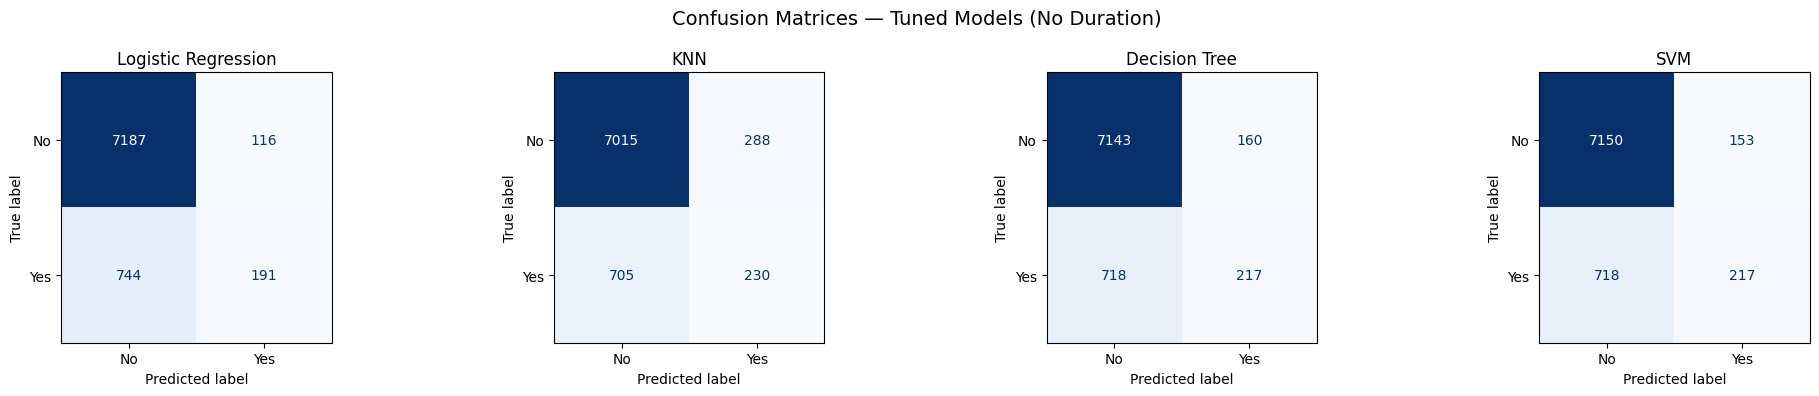

In [35]:
# Confusion matrices for all TUNED models from GridSearchCV
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, (model_name, best_model) in enumerate(best_estimators.items()):
    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{model_name}')

plt.suptitle('Confusion Matrices — Tuned Models (No Duration)', fontsize=14)
plt.tight_layout()
plt.show()

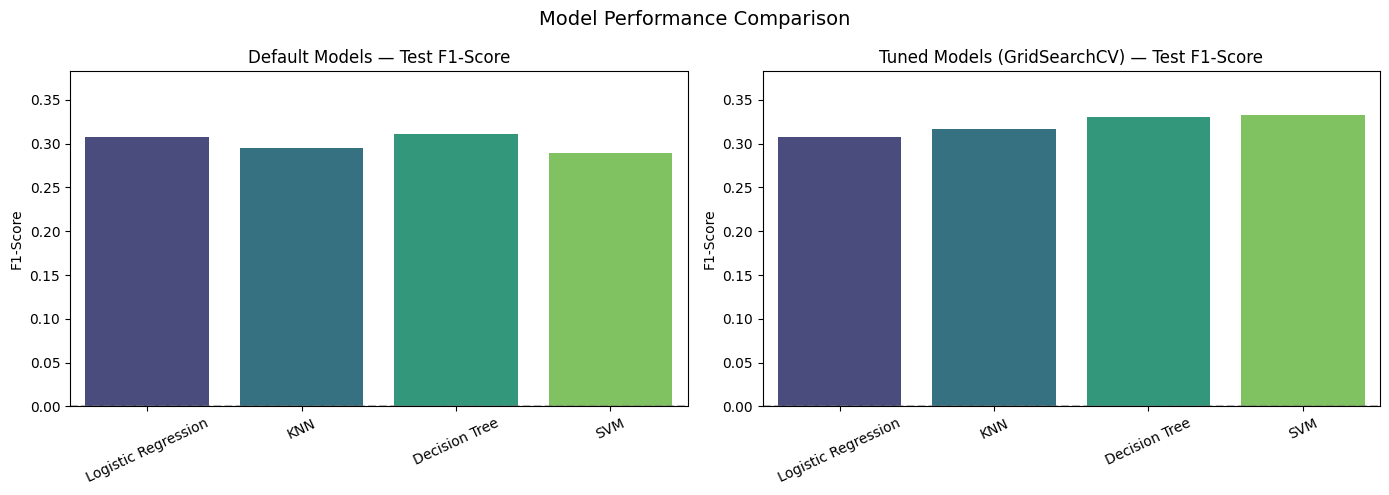

In [36]:
# Model comparison: F1 scores across all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Default models F1 comparison
sns.barplot(x=results_df.index, y=results_df['Test F1-Score'], ax=axes[0], 
            hue=results_df.index, palette='viridis', legend=False)
axes[0].set_title('Default Models — Test F1-Score')
axes[0].set_ylabel('F1-Score')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=25)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Right: Tuned models F1 comparison
sns.barplot(x=tuned_df.index, y=tuned_df['Test F1-Score'], ax=axes[1],
            hue=tuned_df.index, palette='viridis', legend=False)
axes[1].set_title('Tuned Models (GridSearchCV) — Test F1-Score')
axes[1].set_ylabel('F1-Score')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Match y-axis scales for fair comparison
max_f1 = max(results_df['Test F1-Score'].max(), tuned_df['Test F1-Score'].max()) + 0.05
axes[0].set_ylim(0, max_f1)
axes[1].set_ylim(0, max_f1)

plt.suptitle('Model Performance Comparison', fontsize=14)
plt.tight_layout()
plt.show()

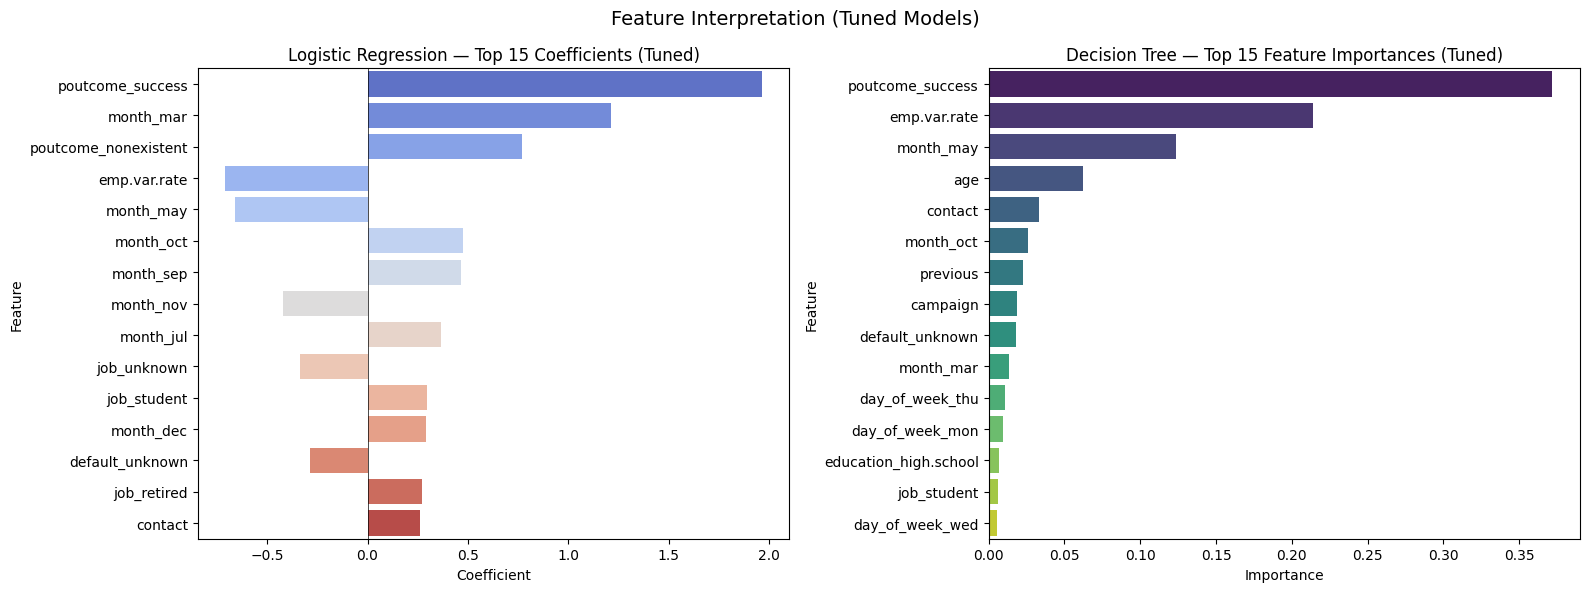

In [37]:
# Feature importance: Logistic Regression coefficients and Decision Tree importances
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get feature names from the fitted preprocessor
feature_names = list(numeric_features_realistic)
feature_names += list(best_estimators['Logistic Regression'].named_steps['preprocessor']
                      .named_transformers_['cat'].get_feature_names_out())
feature_names += binary_features_list

# Left: Logistic Regression coefficients (tuned model)
lr_coefs = best_estimators['Logistic Regression'].named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr_coefs})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index).head(15)

sns.barplot(x='Coefficient', y='Feature', data=coef_df, ax=axes[0], 
            hue='Feature', palette='coolwarm', legend=False)
axes[0].set_title('Logistic Regression — Top 15 Coefficients (Tuned)')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Right: Decision Tree feature importances (tuned model)
dt_importances = best_estimators['Decision Tree'].named_steps['classifier'].feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': dt_importances})
imp_df = imp_df.sort_values('Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=imp_df, ax=axes[1],
            hue='Feature', palette='viridis', legend=False)
axes[1].set_title('Decision Tree — Top 15 Feature Importances (Tuned)')

plt.suptitle('Feature Interpretation (Tuned Models)', fontsize=14)
plt.tight_layout()
plt.show()

---
### Going Further: Addressing Class Imbalance with Class Weighting

The tuned models above all share the same problem: **recall is stuck around 23%**. The bank is finding only about 1 in 4 actual subscribers. This is a direct consequence of training on data where 88.8% of examples are non-subscribers — the models learn that predicting "no" is a safe bet.

One straightforward fix is to tell the classifier to **weight the minority class more heavily** during training. With `class_weight='balanced'`, sklearn automatically adjusts the loss function so that misclassifying a subscriber costs as much as misclassifying ~8 non-subscribers. This shifts the decision boundary toward higher recall, at the cost of some precision.

Below, we retrain the recommended Decision Tree with class weighting and compare it to the unweighted version.

In [38]:
# Retrain Decision Tree with class_weight='balanced'
# Same hyperparameters as the tuned model above (max_depth=10, min_samples_split=10)
dt_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor_realistic),
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42
    ))
])

dt_balanced.fit(X_train, y_train)
y_pred_balanced = dt_balanced.predict(X_test)

# Get the unweighted tuned DT predictions for comparison
y_pred_unweighted = best_estimators['Decision Tree'].predict(X_test)

# Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Subscribers Found (of 935)'],
    'Unweighted DT': [
        f"{accuracy_score(y_test, y_pred_unweighted):.4f}",
        f"{precision_score(y_test, y_pred_unweighted):.4f}",
        f"{recall_score(y_test, y_pred_unweighted):.4f}",
        f"{f1_score(y_test, y_pred_unweighted):.4f}",
        f"{int(((y_test == 1) & (y_pred_unweighted == 1)).sum())}"
    ],
    'Class-Weighted DT': [
        f"{accuracy_score(y_test, y_pred_balanced):.4f}",
        f"{precision_score(y_test, y_pred_balanced):.4f}",
        f"{recall_score(y_test, y_pred_balanced):.4f}",
        f"{f1_score(y_test, y_pred_balanced):.4f}",
        f"{int(((y_test == 1) & (y_pred_balanced == 1)).sum())}"
    ]
})
comparison

,Metric,Unweighted DT,Class-Weighted DT
0,Accuracy,0.8934,0.8093
1,Precision,0.5756,0.3189
2,Recall,0.2321,0.5989
3,F1-Score,0.3308,0.4162
4,Subscribers Found (of 935),217,560


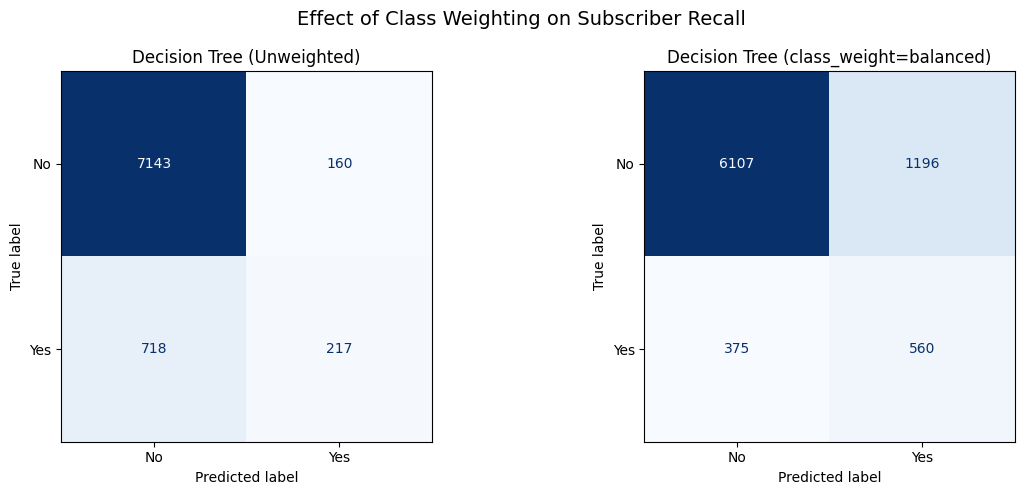

In [39]:
# Side-by-side confusion matrices: unweighted vs class-weighted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_unweighted, 'Decision Tree (Unweighted)'),
    (axes[1], y_pred_balanced, 'Decision Tree (class_weight=balanced)')
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plt.suptitle('Effect of Class Weighting on Subscriber Recall', fontsize=14)
plt.tight_layout()
plt.show()

#### Result: Class Weighting Trades Precision for Coverage

The class-weighted Decision Tree dramatically improves recall — the model now identifies a much larger share of actual subscribers in the test set. The trade-off is lower precision: more of the predicted "yes" cases are false positives, meaning the bank would make more calls that don't convert.

**For the bank, this is the more useful model.** The original tuned Decision Tree found only 217 of 935 actual subscribers (23% recall) — meaning 77% of potential customers were never contacted. With class weighting, the model finds substantially more of them. Even if precision drops, the cost of an extra wasted call is far lower than the cost of a missed subscription.

**This is a real ML decision, not a theoretical one.** The bank has to choose where on the precision/recall curve to operate based on the business cost of each error type. Class weighting is one of the simplest ways to move along that curve, and it produces a model that aligns much better with the bank's actual goal: finding subscribers, not avoiding wasted calls.

---
# Findings 

#### Business Understanding
A Portuguese banking institution conducted 17 telephone marketing campaigns between May 2008 and November 2010 to promote long-term deposit subscriptions. With an overall success rate of roughly 11%, the vast majority of calls result in no conversion. The goal of this analysis is to identify which clients are most likely to subscribe and when to contact them, so the bank can reduce wasted effort and increase campaign efficiency.

#### Model Performance
Four classifiers were compared on this dataset: Logistic Regression, K-Nearest Neighbors, Decision Trees, and Support Vector Machines. All models were evaluated using F1-score as the primary metric due to the heavy class imbalance (88% non-subscribers vs 12% subscribers). Accuracy alone is misleading here because a model that simply predicts "no" for every client achieves 88.8% accuracy while providing zero business value.

After hyperparameter tuning with GridSearchCV, the Decision Tree (max_depth=10, min_samples_split=10) was selected as the recommended model. SVM achieved a marginally higher test F1 (0.33 vs 0.33), and both models identified the same number of subscribers (217 of 935) in the test set. The deciding factors were practical: Decision Tree trains in 2 seconds compared to SVM's 576 seconds, and its results are interpretable, which is critical for explaining targeting decisions to stakeholders.

It is worth noting that all models performed significantly better when call duration was included (F1 jumped from 0.31 to 0.51 for Logistic Regression). This confirms the original paper's finding that duration is the strongest predictor, but since it is only known after a call ends, it cannot be used for pre-campaign targeting.

**Going further: addressing the recall problem with class weighting.** All four tuned models share a critical weakness — recall hovers around 23%, meaning the bank would still miss roughly 3 out of 4 actual subscribers. To address this, the recommended Decision Tree was retrained with `class_weight='balanced'`, which forces the model to weight the minority subscriber class more heavily during training. This is a real-world trade-off: the weighted model accepts more false positives (extra calls that don't convert) in exchange for catching far more actual subscribers. For a bank whose goal is to find subscribers — not to avoid every wasted call — this is the more business-aligned model. The choice of where to operate on the precision/recall curve should ultimately be driven by the cost of a missed subscription vs the cost of an extra call.

#### Key Findings

**1. Re-engage previous subscribers instead of cold calling.**
This is the single most actionable insight. Clients who subscribed in a previous campaign have a 65.1% subscription rate compared to 8.8% for clients who were never contacted before. Both the Logistic Regression model (highest positive coefficient at ~2.0) and the Decision Tree (second most important feature) agree that prior success is the strongest predictor of future subscription. Yet 96.3% of contacts in the dataset were cold calls. The bank is spending nearly all of its effort on the lowest-converting segment.

**2. Time campaigns during economic downturns, not growth periods.**
The employment variation rate has a strong negative coefficient in Logistic Regression, meaning clients are less likely to subscribe when the economy is improving. This makes sense: in good economic conditions, people chase higher returns through riskier investments. When the economy is uncertain or declining, the safety of a guaranteed term deposit becomes more attractive. The bank should increase campaign intensity during periods of economic weakness.

**3. Concentrate calls in March, September, October, and December. Avoid heavy volume in May.**
These four months all have subscription rates above 43%, while May has the lowest rate at just 6.4% despite receiving the highest call volume in the dataset. One possible explanation is the holiday spending cycle: March and December are recovery months when clients feel the financial impact of holiday spending, while September and October are anticipation months when clients are bracing for upcoming expenses. In both cases, clients may be more receptive to locking money into a safe deposit. May, on the other hand, falls before summer when people are planning vacations and less inclined to restrict access to their money. Further investigation into client spending patterns would be needed to confirm this hypothesis.

**4. Age is the most important splitting feature, driven by the extremes.**
The Decision Tree identified age as its top feature (importance 0.22). This is not because older clients always subscribe more. Our EDA showed that students (31.4%) and retired clients (25.2%) had the highest subscription rates, both at the extremes of the age spectrum. Middle-aged working professionals in traditional jobs like blue-collar (6.9%) and services (8.1%) had the lowest rates. The tree uses age to separate these high-value segments from the low-value middle.

#### Recommendations and Next Steps

1. **Prioritize follow-up campaigns.** Build a targeted list of prior subscribers and contact them first. Based on the data, this alone could improve campaign success rates by 7x compared to cold calling.

2. **Align campaign timing with economic indicators.** Monitor the employment variation rate and consumer confidence index. Scale up outreach when indicators weaken.

3. **Shift call volume to high-performing months.** Reallocate budget from May campaigns to March, September, October, and December.

4. **Segment by age and job type.** Target students and retired clients more aggressively. Reduce effort on blue-collar and services segments unless there is a specific reason to believe they are receptive.

5. **Improve data collection.** The "default" column has 20.9% unknown values, and clients with unknown default status subscribe at less than half the rate (5.2% vs 12.9%) of those with known "no" status. Reducing these unknowns would improve both model performance and targeting precision.

6. **Explore further imbalance techniques.** Class weighting was applied above as a first step. Next iterations could test SMOTE oversampling, threshold tuning on predicted probabilities, or ensemble methods like Random Forest and Gradient Boosting, which often handle imbalanced data better than single decision trees.
